### The missing piece of the model: Non-Linearity

'What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?'

or in machine learning terms, an infinite (but really it is finite) Linear and non-linear functions.


### Recreating non-linear data (red and blue circles)



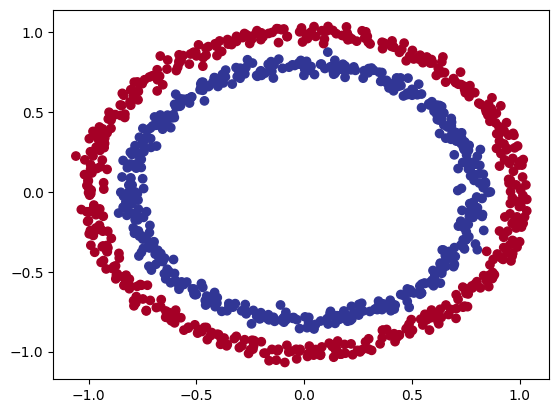

In [47]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import numpy as np

n_samples = 1000

X, y = make_circles(n_samples, 
                    noise = 0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [48]:
# Convert data to tensors and then to train and test splits
import torch 
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                     random_state=42)

device = "cuda" if torch.cuda.is_available() else "cpu"
X_train[:5], y_train[:5]



(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [49]:
### Useful functions 

# Calculate Accuracy - what percentage of the test data did the model predict right? 
# Accuracy = True positive/(True Positive + True Negative) * 100

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc



def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor): 
    
    # Put everything to cpu
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup decision boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))
    
    # Make features 
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make Predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)
        
        # Test for Multi_class or binary classifications and adjust logits to prediction labels
        if len(torch.unique(y)) > 2:
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # Multi-class
        else:
            y_pred = torch.round(torch.sigmoid(y_logits))  # Binary 
        
        # Reshape preds and plot
        y_pred = y_pred.reshape(xx.shape).detach().numpy()
        plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha = 0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap= plt.cm.RdYlBu)
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())

# Building a model with non_linearity 

* Linear =  straight line 
* Non-linear = non-straight lines 

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [50]:
# Build a model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super(). __init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)

In [51]:
loss_fn = nn.BCEWithLogitsLoss()
optimiser = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.01)


In [52]:
# Setting random seeds 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [53]:
### Training The Model
epochs = 10000

for epoch in range(epochs):
    model_3.train()
    
    model_3_logits = model_3(X_train).squeeze()
    model_3_pred = torch.round(torch.sigmoid(model_3_logits))  

    loss = loss_fn(model_3_logits, y_train) # BCEWithLogitsLoss (takes in logits as first input)
    acc = accuracy_fn(y_true = y_train,
                      y_pred = model_3_pred)
    
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # Testing 
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn (y_true=y_test,
                                y_pred= test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% ")
 
            

Epoch: 0 | Loss: 0.6939, Acc: 54.75% | Test Loss: 0.6921, Test Acc: 52.50% 
Epoch: 100 | Loss: 0.6933, Acc: 54.75% | Test Loss: 0.6916, Test Acc: 55.50% 
Epoch: 200 | Loss: 0.6930, Acc: 53.62% | Test Loss: 0.6914, Test Acc: 55.50% 
Epoch: 300 | Loss: 0.6927, Acc: 52.25% | Test Loss: 0.6912, Test Acc: 55.00% 
Epoch: 400 | Loss: 0.6925, Acc: 51.12% | Test Loss: 0.6911, Test Acc: 54.50% 
Epoch: 500 | Loss: 0.6924, Acc: 51.00% | Test Loss: 0.6910, Test Acc: 56.00% 
Epoch: 600 | Loss: 0.6922, Acc: 50.75% | Test Loss: 0.6909, Test Acc: 55.00% 
Epoch: 700 | Loss: 0.6921, Acc: 50.88% | Test Loss: 0.6908, Test Acc: 55.00% 
Epoch: 800 | Loss: 0.6920, Acc: 50.62% | Test Loss: 0.6907, Test Acc: 56.00% 
Epoch: 900 | Loss: 0.6918, Acc: 51.12% | Test Loss: 0.6906, Test Acc: 55.50% 
Epoch: 1000 | Loss: 0.6917, Acc: 50.88% | Test Loss: 0.6905, Test Acc: 55.00% 
Epoch: 1100 | Loss: 0.6915, Acc: 51.12% | Test Loss: 0.6904, Test Acc: 55.50% 
Epoch: 1200 | Loss: 0.6914, Acc: 51.38% | Test Loss: 0.6903, Tes

In [54]:
# Making prediction
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 0., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

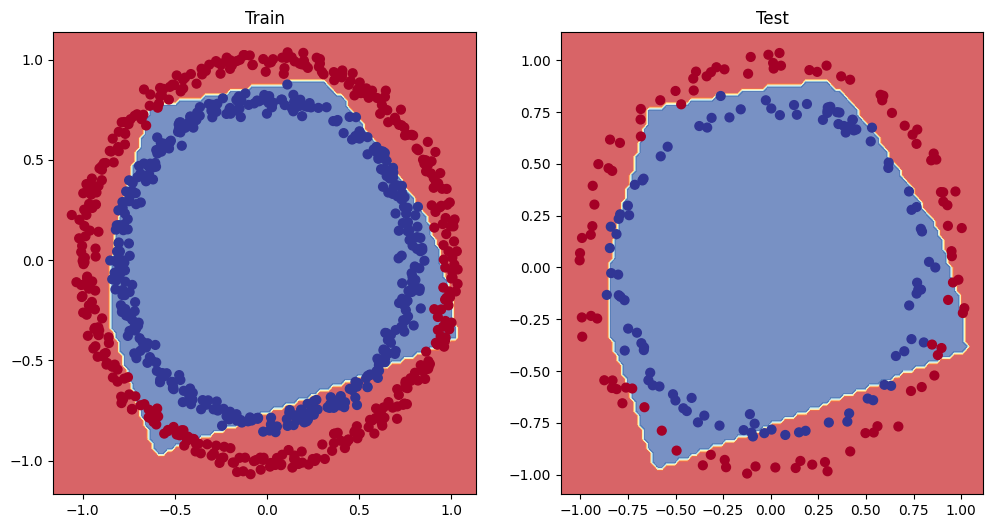

In [55]:
# Plot decision boundary 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)


### Replcating non_linear activation functions 

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on it's own.

And these tools are linear and non-linear functions.

In [56]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A.dtype

torch.float32

In [57]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

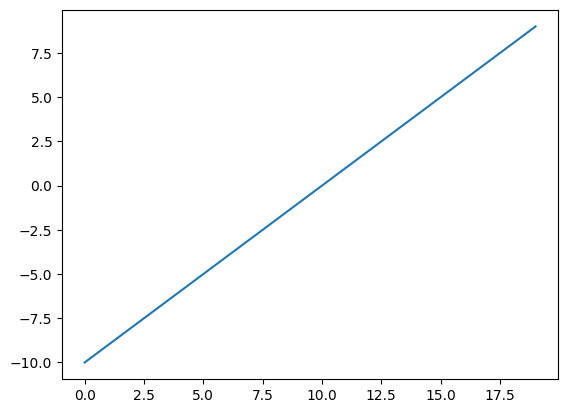

In [58]:
# Visualise the tensor 
plt.plot(A)

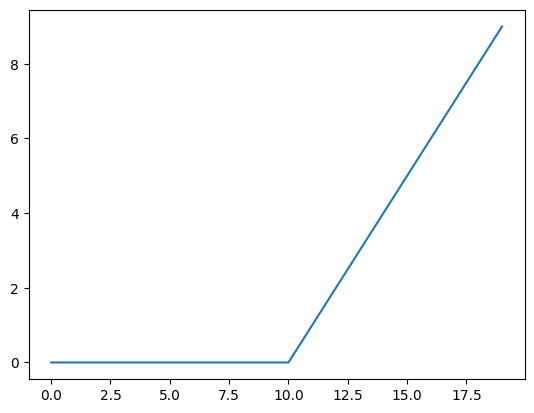

In [59]:
plt.plot(torch.relu(A))

In [60]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # inputs must be tensor

relu(A)


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

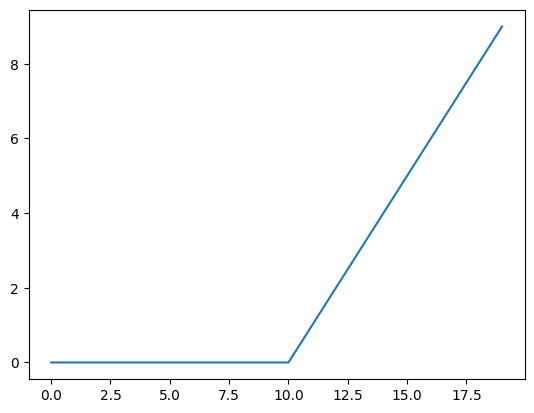

In [61]:
# Plot ReLU activation function

plt.plot(relu(A))

In [62]:
# Doing the same for sigmoid  

def sigmoid(x: torch.Tensor ) -> torch.Tensor: 
    return 1 / (1 + torch.exp(-x))

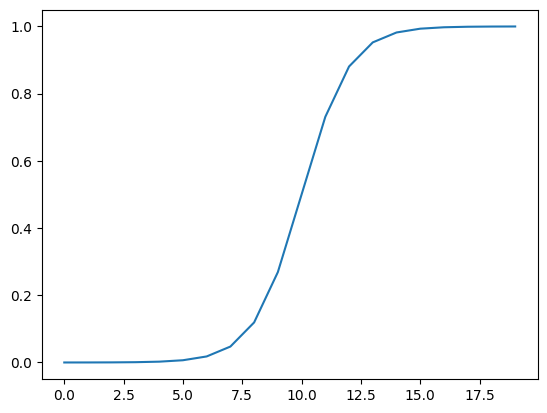

In [63]:
plt.plot(torch.sigmoid(A))

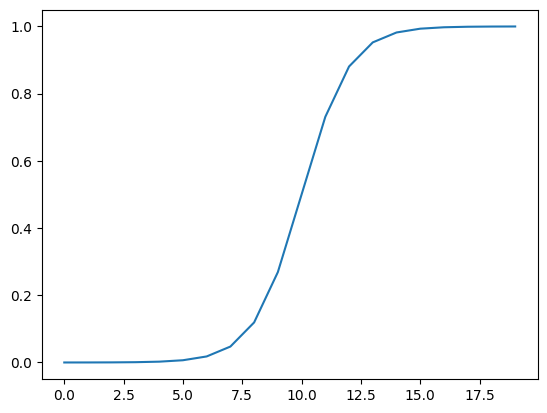

In [64]:
plt.plot(sigmoid(A))

### Putting it all together with a multi-class classification problem

* Binary classification  = one thing or another (cat vs dog, spam or not spam, fraud or not fraud)

* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### Creating a toy multi-class dataset 

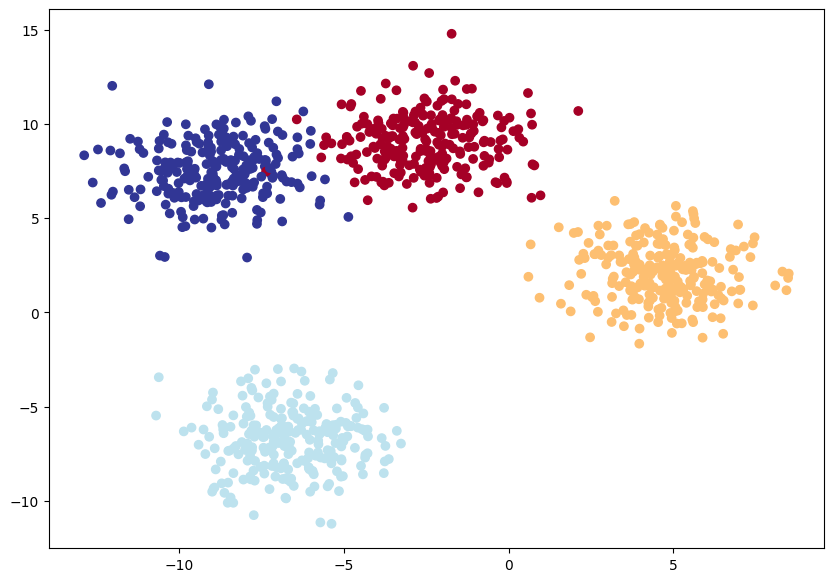

In [65]:
import torch 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the number of hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples = 1000,
                             n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)

# Turn data into tensors 
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# Splt into train and test 
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# plot data (visualize, visualize, visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)


### Building My First Multi-class Classification Model. 

In [66]:
# Create Device agnostic code

device =  "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [67]:
# Build a muilti-class classification model 

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """initialises multi-class classification model
        
        Args: 
        input_features (int): Nummber of input features to teh model
        output_features (int): Number of outputs features (number of output classes)
        hidden_units (int): Number of hiden units between layers, default 8

        Returns:

        Example:
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )  

    def forward(self, x):
        return self.linear_layer_stack(x)
    

# Create an instane of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
 

In [68]:
X_blob_train.shape,  y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

### Creating a loss function and an optimiser for a multi-class classification model



In [69]:
loss_fn = nn.CrossEntropyLoss()
# optimizer 
optimizer = torch.optim.SGD(params = model_4.parameters(),
                            lr = 0.1) ### Learning rate remains an hyperparameter.



### Getting Prediction probabilities for a multi-class PyTorch Model 

in order to evaluate and train the model, we need to convert our model's outputs(logits) to prediction probabilities and then to prediction labels 

Logits --> pred probs --> pred Labels. 

In [71]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_preds[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [72]:
# Convert our logits output to prediction probabilities.

y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_logits[:5])
print(y_pred_probs[:5])


tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [ ]:
# convert our prediction probabilities to prediction labels.

y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds